In [1]:
!pip install datasets transformers sacrebleu sentencepiece matplotlib

In [2]:
import math
import random
import time
from dataclasses import dataclass
from typing import List, Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
# HuggingFace dataset and tokenizer
from datasets import load_dataset
from transformers import AutoTokenizer
# Evaluation
import sacrebleu
# Visualization
import matplotlib.pyplot as plt

/home/arnab/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# -----------------------------
# Configuration / Hyperparams
# -----------------------------
@dataclass
class Config:
    dataset_name: str = "wmt14"
    dataset_config: str = "de-en" # wmt14 has 'de-en'
    src_lang: str = "en"
    tgt_lang: str = "de"
    tokenizer_name: str = "t5-small" # small sentencepiece tokenizer (works for both languages)


    max_len: int = 64 # truncate/pad length for demo
    batch_size: int = 32
    emb_size: int = 512
    nhead: int = 8
    ff_dim: int = 2048
    num_encoder_layers: int = 3
    num_decoder_layers: int = 3
    dropout: float = 0.1
    epochs: int = 3 # keep small for demo
    lr: float = 1e-4
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
print(f"Device: {cfg.device}")

Device: cuda


In [4]:
# -----------------------------
# Utilities: Tokenization + Dataset
# -----------------------------
print("Loading tokenizer... (may download ~ tens of MB)")
tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name)
if tokenizer.pad_token is None:
  tokenizer.add_special_tokens({'pad_token': '<pad>'})

# Load a small subset of WMT14 de-en for demo
print("Loading dataset (this may take a while to download the first time)...")
dataset = load_dataset(cfg.dataset_name, cfg.dataset_config)
# dataset has splits like 'train', 'validation' (may vary). Use small subset for classroom demo

Loading tokenizer... (may download ~ tens of MB)
Loading dataset (this may take a while to download the first time)...


In [5]:
# Create small train/val subsets for the demo to keep runtime small
SMALL_TRAIN = 20000
SMALL_VAL = 1000

def extract_en_de(example):
  # Depending on HF dataset column names
  # For wmt14 'translation' column is a dict with keys 'en' and 'de'
  tr = example['translation']
  return {"en": tr.get('en', ''), "de": tr.get('de', '')}

In [6]:
train_ds = dataset['train'].map(lambda ex: extract_en_de(ex), remove_columns=dataset['train'].column_names)
val_ds = dataset['validation'].map(lambda ex: extract_en_de(ex), remove_columns=dataset['validation'].column_names)

train_ds = train_ds.select(range(min(len(train_ds), SMALL_TRAIN)))
val_ds = val_ds.select(range(min(len(val_ds), SMALL_VAL)))

print(f"Train subset size: {len(train_ds)}, Val subset size: {len(val_ds)}")

Train subset size: 20000, Val subset size: 1000


In [7]:
# Tokenize function
def tokenize_batch(batch):
    src_texts = [x for x in batch['en']]
    tgt_texts = [x for x in batch['de']]
    src = tokenizer(src_texts, max_length=cfg.max_len, truncation=True, padding='max_length', return_tensors='pt')
    tgt = tokenizer(tgt_texts, max_length=cfg.max_len, truncation=True, padding='max_length', return_tensors='pt')
    return {"src_input_ids": src['input_ids'],
            "src_attention_mask": src['attention_mask'],
            "tgt_input_ids": tgt['input_ids'],
            "tgt_attention_mask": tgt['attention_mask']}


# Use dataset.with_format to return py objects and map
train_ds = train_ds.map(lambda ex: tokenize_batch(ex), batched=True, batch_size=cfg.batch_size, remove_columns=train_ds.column_names)
val_ds = val_ds.map(lambda ex: tokenize_batch(ex), batched=True, batch_size=cfg.batch_size, remove_columns=val_ds.column_names)

Map: 100%|██████████| 1000/1000 [00:00<00:00, 7135.22 examples/s]


In [8]:
# DataLoader wrapper
class MTIterableDataset(torch.utils.data.Dataset):
    def __init__(self, hf_ds):
       self.ds = hf_ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        return {k: torch.tensor(v) for k, v in item.items()}

train_loader = DataLoader(MTIterableDataset(train_ds), batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(MTIterableDataset(val_ds), batch_size=cfg.batch_size)

In [9]:
# -----------------------------
# Model: Simple Transformer Seq2Seq
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1) # (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (seq_len, batch, d_model)
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class TransformerMT(nn.Module):
    def __init__(self, vocab_size, emb_size, nhead, ff_dim, num_encoder_layers, num_decoder_layers, dropout=0.1, max_len=512):
        super().__init__()
        self.model_type = 'Transformer'
        self.src_tok_emb = nn.Embedding(vocab_size, emb_size)
        self.tgt_tok_emb = nn.Embedding(vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(emb_size, dropout, max_len)
        self.transformer = nn.Transformer(d_model=emb_size, nhead=nhead,
                                          num_encoder_layers=num_encoder_layers,
                                          num_decoder_layers=num_decoder_layers,
                                          dim_feedforward=ff_dim,
                                          dropout=dropout)
        self.generator = nn.Linear(emb_size, vocab_size)
        self.emb_size = emb_size

    def forward(self, src, tgt, src_mask, tgt_mask, src_key_padding_mask, tgt_key_padding_mask, memory_key_padding_mask):
        # src: (S,N), tgt: (T,N) where N=batch
        src_emb = self.positional_encoding(self.src_tok_emb(src) * math.sqrt(self.emb_size))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(tgt) * math.sqrt(self.emb_size))
        memory = self.transformer.encoder(src_emb, src_key_padding_mask=src_key_padding_mask)
        outs = self.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask,
        tgt_key_padding_mask=tgt_key_padding_mask,
        memory_key_padding_mask=memory_key_padding_mask)
        logits = self.generator(outs)
        return logits
# Helper masks
def generate_square_subsequent_mask(sz):
    mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

In [10]:
# -----------------------------
# Prepare model, loss, optimizer
# -----------------------------
vocab_size = tokenizer.vocab_size
model = TransformerMT(vocab_size=vocab_size, emb_size=cfg.emb_size, nhead=cfg.nhead,
                      ff_dim=cfg.ff_dim, num_encoder_layers=cfg.num_encoder_layers,
                      num_decoder_layers=cfg.num_decoder_layers, dropout=cfg.dropout, max_len=cfg.max_len)

# if tokenizer has added tokens, embeddings need resize
model.src_tok_emb.weight.data.uniform_(-0.1, 0.1)
model.tgt_tok_emb.weight.data.uniform_(-0.1, 0.1)

model.to(cfg.device)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

/home/arnab/miniconda3/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [11]:
# -----------------------------
# Training & Evaluation helpers
# -----------------------------

def create_src_key_padding_mask(attention_mask):
    # attention_mask: (batch, seq_len) -> mask for nn.Transformer expects (batch, seq_len)
    return attention_mask == 0

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        src = batch['src_input_ids'].to(cfg.device).transpose(0,1) # (S, N)
        tgt = batch['tgt_input_ids'].to(cfg.device).transpose(0,1) # (T, N)
        src_mask = None
        tgt_seq_len = tgt.size(0)
        tgt_mask = generate_square_subsequent_mask(tgt_seq_len).to(cfg.device)
        src_key_padding_mask = create_src_key_padding_mask(batch['src_attention_mask']).to(cfg.device)
        tgt_key_padding_mask = create_src_key_padding_mask(batch['tgt_attention_mask']).to(cfg.device)
        memory_key_padding_mask = src_key_padding_mask
        # Teacher forcing: input to decoder is tgt[:-1]
        optimizer.zero_grad()

        output = model(
            src, 
            tgt[:-1, :], 
            src_mask, 
            tgt_mask[:-1, :-1], 
            src_key_padding_mask, 
            tgt_key_padding_mask[:, :-1], 
            memory_key_padding_mask
        )

        # output: (T-1, N, vocab)
        output_flat = output.reshape(-1, output.size(-1))
        target_flat = tgt[1:, :].reshape(-1)
        loss = criterion(output_flat, target_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds = []
    refs = []
    with torch.no_grad():
        for batch in loader:
            src = batch['src_input_ids'].to(cfg.device).transpose(0,1)
            tgt = batch['tgt_input_ids'].to(cfg.device).transpose(0,1)
            # Greedy decode for demo
            memory = model.transformer.encoder(model.positional_encoding(model.src_tok_emb(src) * math.sqrt(model.emb_size)),
            src_key_padding_mask=create_src_key_padding_mask(batch['src_attention_mask']).to(cfg.device))
            ys = torch.ones(1, src.size(1), dtype=torch.long).fill_(tokenizer.pad_token_id).to(cfg.device) # start with pad id for demo
            max_len = cfg.max_len
            for i in range(max_len-1):
                tgt_mask = generate_square_subsequent_mask(ys.size(0)).to(cfg.device)
                out = model.transformer.decoder(model.positional_encoding(model.tgt_tok_emb(ys) * math.sqrt(model.emb_size)), memory, tgt_mask=tgt_mask)
                logits = model.generator(out)
                prob = logits[-1, :, :]
                next_word = torch.argmax(prob, dim=1).unsqueeze(0)
                ys = torch.cat([ys, next_word], dim=0)
            # Convert token ids to strings
            for i in range(src.size(1)):
                pred_tokens = ys[:, i].cpu().numpy()
                # skip initial pad tokens; detokenize
                pred_text = tokenizer.decode([int(x) for x in pred_tokens], skip_special_tokens=True, clean_up_tokenization_spaces=True)
                tgt_text = tokenizer.decode([int(x) for x in tgt[:, i].cpu().numpy()], skip_special_tokens=True, clean_up_tokenization_spaces=True)
                preds.append(pred_text)
                refs.append([tgt_text])

            # compute loss for PPL
            tgt_input = tgt[:-1, :]
            tgt_mask = generate_square_subsequent_mask(tgt_input.size(0)).to(cfg.device)
            src_key_padding_mask = create_src_key_padding_mask(batch['src_attention_mask']).to(cfg.device)
            tgt_key_padding_mask = create_src_key_padding_mask(batch['tgt_attention_mask']).to(cfg.device)
            memory_key_padding_mask = src_key_padding_mask
            output = model(src, tgt_input, None, tgt_mask, src_key_padding_mask, tgt_key_padding_mask[:, :-1], memory_key_padding_mask)
            output_flat = output.reshape(-1, output.size(-1))
            target_flat = tgt[1:, :].reshape(-1)
            loss = criterion(output_flat, target_flat)
            total_loss += loss.item()

    # BLEU using sacrebleu (corpus_bleu) expects list of references lists
    bleu = sacrebleu.corpus_bleu(preds, list(zip(*refs))) # preds, (refs1, refs2,...)
    # Perplexity
    ppl = math.exp(total_loss / len(loader))
    return bleu.score, ppl

/home/arnab/miniconda3/lib/python3.13/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch 1/3 -- train_loss: 5.5167 -- val BLEU: 0.09 -- val PPL: 410.73 -- time: 145.1s
Epoch 2/3 -- train_loss: 4.3503 -- val BLEU: 0.17 -- val PPL: 301.28 -- time: 146.1s
Epoch 3/3 -- train_loss: 3.9088 -- val BLEU: 0.25 -- val PPL: 257.16 -- time: 146.4s


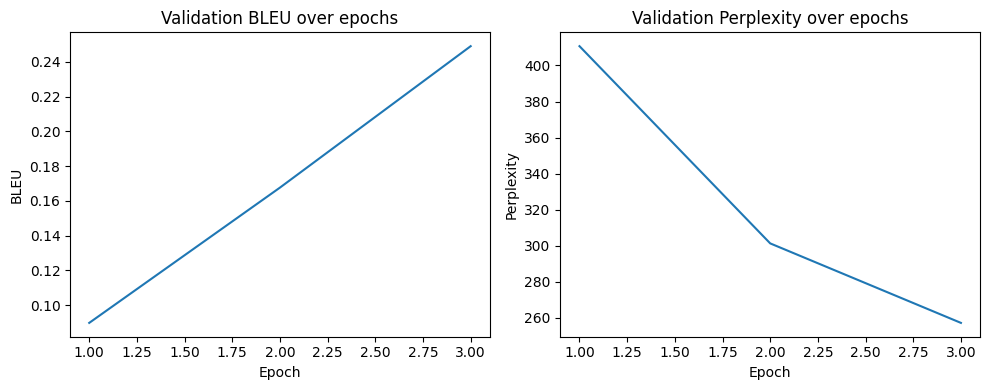

In [12]:
# -----------------------------
# Training loop with visualization
# -----------------------------
bleu_history = []
pppl_history = []
loss_history = []

for epoch in range(cfg.epochs):
    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    bleu_score, ppl = evaluate(model, val_loader, criterion)
    bleu_history.append(bleu_score)
    pppl_history.append(ppl)
    loss_history.append(train_loss)
    end = time.time()
    print(f"Epoch {epoch+1}/{cfg.epochs} -- train_loss: {train_loss:.4f} -- val BLEU: {bleu_score:.2f} -- val PPL: {ppl:.2f} -- time: {end-start:.1f}s")

# Plot BLEU and PPL
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, len(bleu_history)+1), bleu_history)
plt.title('Validation BLEU over epochs')
plt.xlabel('Epoch')
plt.ylabel('BLEU')

plt.subplot(1,2,2)
plt.plot(range(1, len(pppl_history)+1), pppl_history)
plt.title('Validation Perplexity over epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')

plt.tight_layout()
plt.show()

In [13]:
# -----------------------------
# Save a small checkpoint
# -----------------------------
torch.save({'model_state_dict': model.state_dict(), 'tokenizer': tokenizer.get_vocab()}, 'transformer_mt_demo_checkpoint.pt')
print('Saved checkpoint: transformer_mt_demo_checkpoint.pt')

Saved checkpoint: transformer_mt_demo_checkpoint.pt


#LAB_QUESTIONS

#1) **Increasing number of layers:**[1+2+2 = 5Marks]

##a. Experiment: Increase encoder and/or decoder layers (e.g., 3 -> 6 -> 12). What happens to BLEU and PPL on the validation subset? Plot BLEU/PPL vs number of layers.

##b. Why might increasing layers sometimes *decrease* BLEU on a small subset? (Hint: overfitting, optimization difficulty, insufficient data).

##c. Suggest two ways to stabilize training when increasing depth (e.g., learning rate schedule, layer normalization modifications, warmup steps).

---
### Q1 ANSWERS


Training model with 3 encoder layers and 3 decoder layers
BLEU: 0.14, PPL: 255.46

Training model with 6 encoder layers and 6 decoder layers
BLEU: 0.19, PPL: 272.00

Training model with 12 encoder layers and 12 decoder layers
BLEU: 0.00, PPL: 1209.67


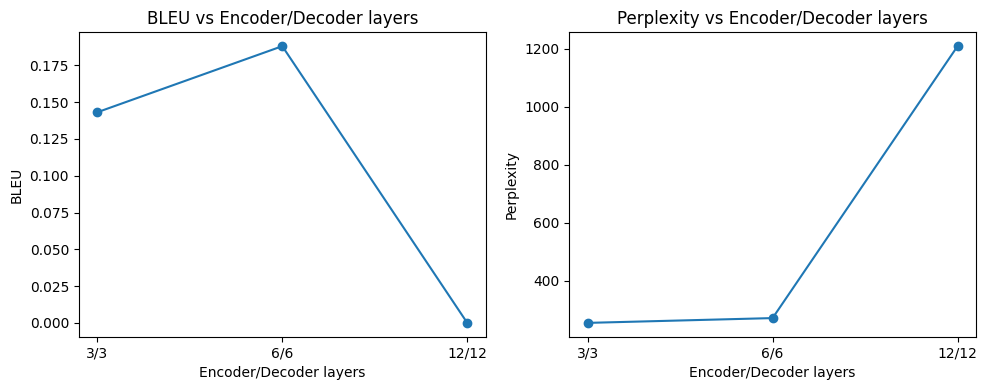

In [14]:
# 1a.VARYING ENCODER/DECODER LAYERS
layer_settings = [(3,3), (6,6), (12,12)]
bleu_layers = []
ppl_layers = []

for enc_layers, dec_layers in layer_settings:
    print(f"\nTraining model with {enc_layers} encoder layers and {dec_layers} decoder layers")
    
    model = TransformerMT(vocab_size=vocab_size, emb_size=cfg.emb_size, nhead=cfg.nhead,
                          ff_dim=cfg.ff_dim, num_encoder_layers=enc_layers,
                          num_decoder_layers=dec_layers, dropout=cfg.dropout, max_len=cfg.max_len)
    model.to(cfg.device)
    model.src_tok_emb.weight.data.uniform_(-0.1, 0.1)
    model.tgt_tok_emb.weight.data.uniform_(-0.1, 0.1)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    
    # Train for few epochs for demo
    for epoch in range(3):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
    
    bleu_score, ppl = evaluate(model, val_loader, criterion)
    print(f"BLEU: {bleu_score:.2f}, PPL: {ppl:.2f}")
    
    bleu_layers.append(bleu_score)
    ppl_layers.append(ppl)

# Plot BLEU/PPL vs number of layers
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot([f"{e}/{d}" for e,d in layer_settings], bleu_layers, marker='o')
plt.title('BLEU vs Encoder/Decoder layers')
plt.xlabel('Encoder/Decoder layers')
plt.ylabel('BLEU')

plt.subplot(1,2,2)
plt.plot([f"{e}/{d}" for e,d in layer_settings], ppl_layers, marker='o')
plt.title('Perplexity vs Encoder/Decoder layers')
plt.xlabel('Encoder/Decoder layers')
plt.ylabel('Perplexity')
plt.tight_layout()
plt.show()


### 1b:-
- Deeper models have higher parameters -> easier to memorise entire dataset -> overfitting + lowers BLEU
- limited data, deeper model, harder to converge affectively
- more layers, harder to train, increases chances of exploding/vanishing gradients

### 1c:-
- Normalizaton and regularisation stabilises gradident flow, most reliable method to dodge exploding and vanishing gradients
- dropout can reduce overfitting
- use learning rate schedulers with warm up and decay values

---

#2) **Masked attention importance:**[2+1+2 = 5Marks]

##a. In the decoder, the autoregressive mask (subsequent mask) prevents positions from attending to future tokens. Remove the mask and observe the effect on translation quality. Report BLEU and qualitative examples.

##b. Explain why the mask is required during training when using teacher forcing and during inference.(Think what is teacher forcing first!!)

##c. Design an experiment to measure how often the decoder uses "future" tokens when mask is removed (hint: attention weight visualization for decoder self-attention).

---
### Q2 ANSWERS

In [15]:
# Q2 A answer implementation
def evaluate_no_mask(model, loader, criterion):
    model.eval()
    preds = []
    refs = []
    with torch.no_grad():
        for batch in loader:
            src = batch['src_input_ids'].to(cfg.device).transpose(0,1)
            tgt = batch['tgt_input_ids'].to(cfg.device).transpose(0,1)
            memory = model.transformer.encoder(
                model.positional_encoding(model.src_tok_emb(src) * math.sqrt(model.emb_size)),
                src_key_padding_mask=create_src_key_padding_mask(batch['src_attention_mask']).to(cfg.device)
            )
            ys = torch.ones(1, src.size(1), dtype=torch.long).fill_(tokenizer.pad_token_id).to(cfg.device)
            for i in range(cfg.max_len-1):
                
                # ---removing mask here---
                out = model.transformer.decoder(
                    model.positional_encoding(model.tgt_tok_emb(ys) * math.sqrt(model.emb_size)),
                    memory
                )

                logits = model.generator(out)
                next_word = torch.argmax(logits[-1, :, :], dim=1).unsqueeze(0)
                ys = torch.cat([ys, next_word], dim=0)

            # Detokenize
            for i in range(src.size(1)):
                pred_text = tokenizer.decode([int(x) for x in ys[:,i].cpu().numpy()], skip_special_tokens=True)
                tgt_text = tokenizer.decode([int(x) for x in tgt[:,i].cpu().numpy()], skip_special_tokens=True)
                preds.append(pred_text)
                refs.append([tgt_text])

    bleu = sacrebleu.corpus_bleu(preds, list(zip(*refs)))
    print(f"BLEU without mask: {bleu.score:.2f}")
    return preds[:5], refs[:5]  # 5 qualitiaative examples as instructed

examples_pred, examples_ref = evaluate_no_mask(model, val_loader, criterion)
for p, r in zip(examples_pred, examples_ref):
    print(f"Pred: {p}\nRef: {r[0]}\n---")


BLEU without mask: 0.00
Pred:                                                               
Ref: Eine republikanische Strategie, um der Wiederwahl von Obama entgegenzutreten
---
Pred:                                                               
Ref: Die Führungskräfte der Republikaner rechtfertigen ihre Politik mit der Notwendigkeit, den Wahlbetrug zu bekämpfen.
---
Pred:                                                               
Ref: Allerdings hält das Brennan Center letzteres für einen Mythos, indem es bekräftigt, dass der Wahlbetrug in den USA seltener ist als die Anzahl der vom Blitzschlag getöteten Menschen.
---
Pred:                                                               
Ref: Die Rechtsanwälte der Republikaner haben in 10 Jahren in den USA übrigens nur 300 Fälle von Wahlbetrug verzeichnet.
---
Pred:                                                               
Ref: Eins ist sicher: diese neuen Bestimmungen werden sich negativ auf die Wahlbeteiligung auswirken.
--

### 2b:-
- without mask, each position can see future tokens in sequence breaking the autoregressive chain + allowing the model to effectively cheat without learning properly.
- During the inference itself, if the model thinks about future tokens, it breaks sequential generation logic, for which causal dependency (i.e the upper traingular matrix) is necessary to maintain dependency only on previous tokens.

In [16]:
!pip install seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


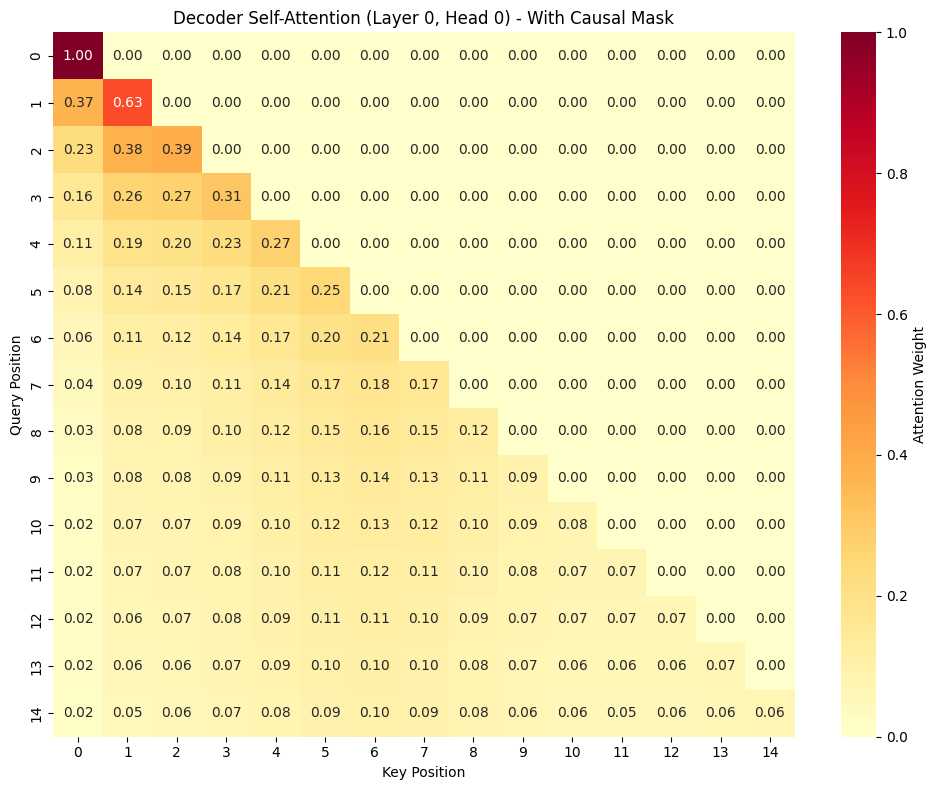

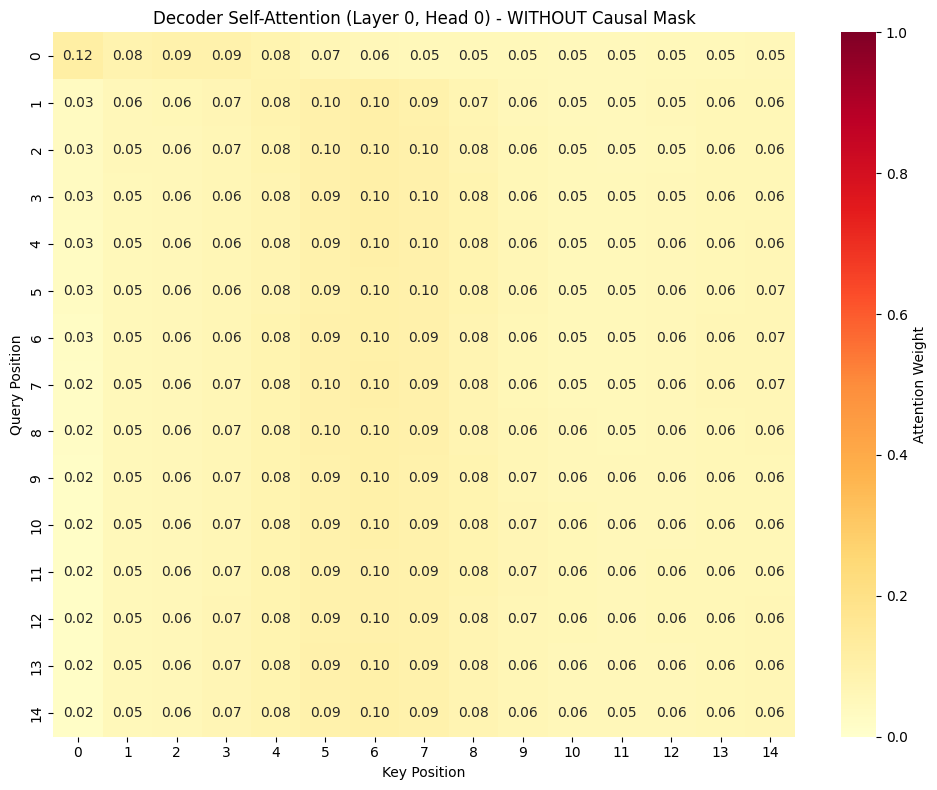

In [26]:
import seaborn as sns
import numpy as np

def visualize_decoder_attention_proper(model, src_sentence, max_decode_len=15):
    """
    Visualising decoder attenntion with causal mask to see how it prevents future attention.
    """
    model.eval()
    
    src_ids=tokenizer(
        src_sentence, 
        return_tensors='pt', 
        max_length=cfg.max_len, 
        truncation=True, 
        padding='max_length'
    )['input_ids'].to(cfg.device)

    src=src_ids.transpose(0, 1)
    
    src_emb=model.positional_encoding(model.src_tok_emb(src) * math.sqrt(model.emb_size))
    memory=model.transformer.encoder(src_emb)

    ys = src_ids[:, :1].transpose(0, 1)  # first start token
    
    # storing attention weights for plotting
    attention_weights_list=[]
    all_attention_steps=[]
    
    # Hook to capture attention weights with need_weights=True for plotting heatmap
    def hook_fn(module, input, output):
        if output[1] is not None:
            attention_weights_list.append(output[1].detach().cpu())
    
    # Temporarily modify self_attn to always return weights, without modifications or normalization for graph plotting
    original_forward = model.transformer.decoder.layers[0].self_attn.forward
    
    def modified_forward(query, key, value, key_padding_mask=None, need_weights=True, attn_mask=None, average_attn_weights=False, is_causal=False):
        return original_forward(
            query, 
            key, 
            value, 
            key_padding_mask=key_padding_mask,
                               need_weights=True, attn_mask=attn_mask, 
                               average_attn_weights=False, is_causal=is_causal)
    
    model.transformer.decoder.layers[0].self_attn.forward = modified_forward
    hook=model.transformer.decoder.layers[0].self_attn.register_forward_hook(hook_fn)

    with torch.no_grad():
        for i in range(max_decode_len):
            tgt_mask = generate_square_subsequent_mask(ys.size(0)).to(cfg.device)
            tgt_emb = model.positional_encoding(model.tgt_tok_emb(ys) * math.sqrt(model.emb_size))
            
            attention_weights_list.clear()

            output = model.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask)
            logits = model.generator(output)
            
            next_token = torch.argmax(logits[-1, :, :], dim=1).unsqueeze(0)
            ys = torch.cat([ys, next_token], dim=0)
            
            # Store attention from this step
            if len(attention_weights_list) > 0:
                attn_tensor = attention_weights_list[0]
                if attn_tensor.dim() == 4:
                    attn = attn_tensor[0, 0]
                elif attn_tensor.dim() == 3:
                    attn = attn_tensor[0]
                else:
                    continue
                    
                all_attention_steps.append(attn.numpy())
                seq_len = attn.shape[0]
                future_attn_sum = 0
                for pos in range(seq_len):
                    future_attn_sum += attn[pos, pos+1:].sum().item()

    model.transformer.decoder.layers[0].self_attn.forward = original_forward
    hook.remove()
    
    # visualization of last attention matrix via heatmap
    final_attn = all_attention_steps[-1]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(final_attn, annot=True, fmt='.2f', cmap='YlOrRd', 
                cbar_kws={'label': 'Attention Weight'}, vmin=0, vmax=1)
    plt.title('Decoder Self-Attention (Layer 0, Head 0) - With Causal Mask')
    plt.xlabel('Key Position')
    plt.ylabel('Query Position')
    plt.tight_layout()
    plt.show()


def visualize_decoder_attention_NO_MASK(model, src_sentence, max_decode_len=15):
    """
    Same visualization but WITHOUT causal mask to see future attention.
    Demonstrates why masking is necesary for sequential generation.
    """

    #same code as above
    model.eval()
    
    src_ids = tokenizer(src_sentence, return_tensors='pt', max_length=cfg.max_len, 
                       truncation=True, padding='max_length')['input_ids'].to(cfg.device)
    src = src_ids.transpose(0, 1)
    
    src_emb = model.positional_encoding(model.src_tok_emb(src) * math.sqrt(model.emb_size))
    memory = model.transformer.encoder(src_emb)
    
    ys = src_ids[:, :1].transpose(0, 1)
    
    attention_weights_list = []
    all_attention_steps = []
    
    def hook_fn(module, input, output):
        if output[1] is not None:
            attention_weights_list.append(output[1].detach().cpu())

    original_forward = model.transformer.decoder.layers[0].self_attn.forward
    
    def modified_forward(query, key, value, key_padding_mask=None, need_weights=True, 
                        attn_mask=None, average_attn_weights=False, is_causal=False):
        return original_forward(query, key, value, key_padding_mask=key_padding_mask,
                               need_weights=True, attn_mask=attn_mask, 
                               average_attn_weights=False, is_causal=is_causal)
    
    model.transformer.decoder.layers[0].self_attn.forward = modified_forward
    hook = model.transformer.decoder.layers[0].self_attn.register_forward_hook(hook_fn)
    
    with torch.no_grad():
        for i in range(max_decode_len):

            # --- REMOVING MASK HERE
            tgt_mask = None
            tgt_emb = model.positional_encoding(model.tgt_tok_emb(ys) * math.sqrt(model.emb_size))
            
            attention_weights_list.clear()
            output = model.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask)
            logits = model.generator(output)
            
            next_token = torch.argmax(logits[-1, :, :], dim=1).unsqueeze(0)
            ys = torch.cat([ys, next_token], dim=0)
            
            if len(attention_weights_list) > 0:
                attn_tensor = attention_weights_list[0]
                if attn_tensor.dim() == 4:
                    attn = attn_tensor[0, 0]
                elif attn_tensor.dim() == 3:
                    attn = attn_tensor[0]
                else:
                    continue
                    
                all_attention_steps.append(attn.numpy())
                
                seq_len = attn.shape[0]
                future_attn_sum = 0
                for pos in range(seq_len):
                    future_attn_sum += attn[pos, pos+1:].sum().item()
    
    model.transformer.decoder.layers[0].self_attn.forward = original_forward
    hook.remove()
    
    final_attn = all_attention_steps[-1]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(final_attn, annot=True, fmt='.2f', cmap='YlOrRd',
                cbar_kws={'label': 'Attention Weight'}, vmin=0, vmax=1)
    plt.title('Decoder Self-Attention (Layer 0, Head 0) - WITHOUT Causal Mask')
    plt.xlabel('Key Position')
    plt.ylabel('Query Position')
    plt.tight_layout()
    plt.show()
    
visualize_decoder_attention_proper(model, "CSD456 is a deep learning course taught by professor Saurabh Shigwan.")

visualize_decoder_attention_NO_MASK(model, "CSD456 is a deep learning course taught by professor Saurabh Shigwan.")

As observable without masking all tokens irrespective of position are visible which violate sequential generation

---